# Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass
from sqlalchemy import create_engine, URL

In [3]:
df = pd.read_csv("amberleaf_orders.csv")
df.head()

,Order ID,Customer ID,Order Date,Category,Product Name,Unit Price (GBP),Quantity,Discount %,Region,Channel,Customer Segment,Payment Method,Review Rating,Returned,Previous Orders
0,101319,5404,2025-11-05,Bedding,Pillow Pair,33.82,2,20,South East,Online,New,Card,2.8,No,3
1,100505,5246,2025-02-01,Decor,Ceramic Vase,54.27,4,5,North East,Online,VIP,Card,3.4,No,4
2,101942,5227,2026-01-27,Bedding,Linen Duvet Set,33.30,2,5,South West,Online,New,PayPal,4.1,Yes,2
3,101073,5680,2025-10-24,Bedding,Mattress Topper,24.19,1,0,Wales,In-Store,New,Klarna,4.6,No,3
4,100111,5249,2025-05-08,Storage,Storage Ottoman,42.15,1,0,Wales,Online,New,Card,3.9,No,3


In [4]:
df.describe()

,Order ID,Customer ID,Unit Price (GBP),Quantity,Discount %,Review Rating,Previous Orders
count,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2172.000000,2218.000000
mean,101101.090622,5453.066276,44.110987,2.017133,4.664112,4.022376,3.201984
std,635.076815,259.511309,18.511675,1.068124,7.129031,0.774172,1.809052
min,100001.000000,5001.000000,-65.970000,1.000000,0.000000,1.200000,0.000000
25%,100551.250000,5231.250000,31.577500,1.000000,0.000000,3.500000,2.000000
50%,101101.500000,5454.000000,41.150000,2.000000,0.000000,4.100000,3.000000
75%,101649.750000,5678.000000,54.495000,3.000000,10.000000,4.700000,4.000000
max,102200.000000,5899.000000,170.360000,4.000000,25.000000,5.000000,11.000000


In [5]:
(df[df["Unit Price (GBP)"] <= 0])

,Order ID,Customer ID,Order Date,Category,Product Name,Unit Price (GBP),Quantity,Discount %,Region,Channel,Customer Segment,Payment Method,Review Rating,Returned,Previous Orders
847,100465,5005,2025-04-08,Furniture,Bar Stool,-60.94,3,5,South East,Online,Returning,Gift Card,2.9,No,2
1042,101476,5271,2025-07-16,Storage,Shoe Rack,-31.60,1,0,South West,In-Store,New,Card,2.8,No,2
1214,101823,5271,2025-09-04,Lighting,Desk Lamp,-65.97,1,0,North East,Online,New,Card,3.1,No,1
1562,100120,5103,2025-12-19,Storage,Drawer Organiser,-45.11,1,0,South West,Online,Returning,Klarna,4.0,No,2
1589,101990,5831,2026-02-14,Furniture,Coffee Table,-30.87,1,5,Midlands,Online,VIP,Card,4.9,No,0
1912,100127,5071,2025-06-05,Kitchen,Cast Iron Pan,-53.79,4,0,Midlands,Online,New,Gift Card,4.0,No,1


In [6]:
df[["Product Name","Unit Price (GBP)"]].head(20)

,Product Name,Unit Price (GBP)
0,Pillow Pair,33.82
1,Ceramic Vase,54.27
2,Linen Duvet Set,33.30
3,Mattress Topper,24.19
4,Storage Ottoman,42.15
5,Console Table,33.43
6,Shoe Rack,63.80
7,Pendant Light,35.05
8,Pendant Light,23.27
9,Coffee Table,73.96


In [7]:
negative_prices = df["Unit Price (GBP)"] <= 0

product_mean = (
    df["Unit Price (GBP)"]
    .where(df["Unit Price (GBP)"] > 0)
    .groupby(df["Product Name"])
    .transform("mean")
)

df.loc[negative_prices, "Unit Price (GBP)"] = product_mean[negative_prices]

In [8]:
(df[df["Unit Price (GBP)"] <= 0])

,Order ID,Customer ID,Order Date,Category,Product Name,Unit Price (GBP),Quantity,Discount %,Region,Channel,Customer Segment,Payment Method,Review Rating,Returned,Previous Orders


Negative values are replaced with the mean of their respective products

In [9]:
df.isna().sum()

Order ID             0
Customer ID          0
Order Date           0
Category             0
Product Name         0
Unit Price (GBP)     0
Quantity             0
Discount %           0
Region              20
Channel              0
Customer Segment     0
Payment Method       0
Review Rating       46
Returned             0
Previous Orders      0
dtype: int64

In [10]:
print(df["Product Name"].value_counts())


Product Name
Chopping Board      113
Cast Iron Pan       110
Kettle              103
Mattress Topper      93
Knife Block          92
Cushion Cover        90
Ceramic Mug Set      87
Wall Mirror          84
Framed Print         82
Wool Throw           81
Pillow Pair          78
Pendant Light        77
Floor Lamp           76
Candle Set           76
Ceramic Vase         74
Linen Duvet Set      71
Wall Shelf Unit      69
Drawer Organiser     68
Shoe Rack            64
Fairy Lights         64
Laundry Basket       63
Storage Ottoman      63
Accent Chair         61
Oak Bookshelf        60
Woven Basket         58
Desk Lamp            55
Table Lamp           54
Coffee Table         53
Console Table        51
Bar Stool            48
Name: count, dtype: int64


In [11]:
print(df["Category"].value_counts())

Category
Kitchen        489
Bedding        395
Decor          358
Storage        314
Lighting       313
Furniture      261
bedding         14
decor           12
kitchen         10
storage          8
lighting         7
furniture        7
Lighting         5
Storage          5
Furniture        5
Kitchen          5
Bedding          4
Decor            3
lighting         1
kitchen          1
decor            1
Name: count, dtype: int64


 [1] 20  enteries (<1% ) with unkown regions are to be dropped.  
 [2] Unkown review ratings to be imputed using the median rating for every individual product rarher than category which exhibt a significant class imblance.

In [12]:
df["Review Rating"] = df.groupby("Product Name")["Review Rating"].transform(lambda x: x.fillna(x.median()))
df = df.dropna()
df.isna().sum()

Order ID            0
Customer ID         0
Order Date          0
Category            0
Product Name        0
Unit Price (GBP)    0
Quantity            0
Discount %          0
Region              0
Channel             0
Customer Segment    0
Payment Method      0
Review Rating       0
Returned            0
Previous Orders     0
dtype: int64

It's also noticed from above that some categories have inconsistent naming. Hence, a further investigation to be conducted

In [13]:
print(df["Category"].unique())
print(df["Product Name"].unique())

['Bedding' 'Decor' 'Storage' 'Furniture' 'Lighting' 'Kitchen' 'storage'
 'bedding' 'lighting' 'Storage  ' 'Lighting  ' 'kitchen' 'decor'
 'Bedding  ' 'lighting  ' 'furniture' 'Furniture  ' 'Kitchen  ' 'Decor  '
 'kitchen  ' 'decor  ']
['Pillow Pair' 'Ceramic Vase' 'Linen Duvet Set' 'Mattress Topper'
 'Storage Ottoman' 'Console Table' 'Shoe Rack' 'Pendant Light'
 'Coffee Table' 'Kettle' 'Fairy Lights' 'Wall Shelf Unit' 'Wall Mirror'
 'Accent Chair' 'Floor Lamp' 'Laundry Basket' 'Chopping Board'
 'Woven Basket' 'Wool Throw' 'Cast Iron Pan' 'Knife Block' 'Candle Set'
 'Drawer Organiser' 'Desk Lamp' 'Cushion Cover' 'Ceramic Mug Set'
 'Framed Print' 'Oak Bookshelf' 'Table Lamp' 'Bar Stool']


In [14]:
# df["Category"] = df["Category"].str.strip()
df["Product Name"] = df["Product Name"].str.strip()
mapping_categories_names = {"bedding": "Bedding", "kitchen": "Kitchen", "storage": "Storage", "decor":"Decor", "furniture" : "Furniture", "lighting": "Lighting"}
df["Category"] = df["Category"].str.strip().str.lower().map(mapping_categories_names)


In [15]:
print(df["Category"].unique())

['Bedding' 'Decor' 'Storage' 'Furniture' 'Lighting' 'Kitchen']


In [16]:
print(df.duplicated().sum())

18


18 duplicated orders to be dropped ( < 0.5% of entries)

In [17]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2180 entries, 0 to 2217
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          2180 non-null   int64  
 1   Customer ID       2180 non-null   int64  
 2   Order Date        2180 non-null   object 
 3   Category          2180 non-null   object 
 4   Product Name      2180 non-null   object 
 5   Unit Price (GBP)  2180 non-null   float64
 6   Quantity          2180 non-null   int64  
 7   Discount %        2180 non-null   int64  
 8   Region            2180 non-null   object 
 9   Channel           2180 non-null   object 
 10  Customer Segment  2180 non-null   object 
 11  Payment Method    2180 non-null   object 
 12  Review Rating     2180 non-null   float64
 13  Returned          2180 non-null   object 
 14  Previous Orders   2180 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 272.5+ KB


In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

Different timestep variables to potentially gain a further understanding of ordering habits

In [20]:
df["month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.dayofweek
df["month"] = df["Order Date"].dt.month

In [21]:
df.head()

,Order ID,Customer ID,Order Date,Category,Product Name,Unit Price (GBP),Quantity,Discount %,Region,Channel,Customer Segment,Payment Method,Review Rating,Returned,Previous Orders,month,Day
0,101319,5404,2025-11-05,Bedding,Pillow Pair,33.82,2,20,South East,Online,New,Card,2.8,No,3,11,2
1,100505,5246,2025-02-01,Decor,Ceramic Vase,54.27,4,5,North East,Online,VIP,Card,3.4,No,4,2,5
2,101942,5227,2026-01-27,Bedding,Linen Duvet Set,33.30,2,5,South West,Online,New,PayPal,4.1,Yes,2,1,1
3,101073,5680,2025-10-24,Bedding,Mattress Topper,24.19,1,0,Wales,In-Store,New,Klarna,4.6,No,3,10,4
4,100111,5249,2025-05-08,Storage,Storage Ottoman,42.15,1,0,Wales,Online,New,Card,3.9,No,3,5,3


In [22]:
df = df.rename(columns={"Unit Price (GBP)": "unit_price", "Discount %": "discount_percentage"})
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")
df.head()


,order_id,customer_id,order_date,category,product_name,unit_price,quantity,discount_percentage,region,channel,customer_segment,payment_method,review_rating,returned,previous_orders,month,day
0,101319,5404,2025-11-05,Bedding,Pillow Pair,33.82,2,20,South East,Online,New,Card,2.8,No,3,11,2
1,100505,5246,2025-02-01,Decor,Ceramic Vase,54.27,4,5,North East,Online,VIP,Card,3.4,No,4,2,5
2,101942,5227,2026-01-27,Bedding,Linen Duvet Set,33.30,2,5,South West,Online,New,PayPal,4.1,Yes,2,1,1
3,101073,5680,2025-10-24,Bedding,Mattress Topper,24.19,1,0,Wales,In-Store,New,Klarna,4.6,No,3,10,4
4,100111,5249,2025-05-08,Storage,Storage Ottoman,42.15,1,0,Wales,Online,New,Card,3.9,No,3,5,3


In [23]:
df["revenue"] = df["unit_price"] * df["quantity"] - (df["unit_price"] * df["quantity"]* (df["discount_percentage"]/100))

Having a revenue column will give us a clearer understaing of the performace of individual products across different timesteps

In [24]:
df.head()

,order_id,customer_id,order_date,category,product_name,unit_price,quantity,discount_percentage,region,channel,customer_segment,payment_method,review_rating,returned,previous_orders,month,day,revenue
0,101319,5404,2025-11-05,Bedding,Pillow Pair,33.82,2,20,South East,Online,New,Card,2.8,No,3,11,2,54.112
1,100505,5246,2025-02-01,Decor,Ceramic Vase,54.27,4,5,North East,Online,VIP,Card,3.4,No,4,2,5,206.226
2,101942,5227,2026-01-27,Bedding,Linen Duvet Set,33.30,2,5,South West,Online,New,PayPal,4.1,Yes,2,1,1,63.270
3,101073,5680,2025-10-24,Bedding,Mattress Topper,24.19,1,0,Wales,In-Store,New,Klarna,4.6,No,3,10,4,24.190
4,100111,5249,2025-05-08,Storage,Storage Ottoman,42.15,1,0,Wales,Online,New,Card,3.9,No,3,5,3,42.150


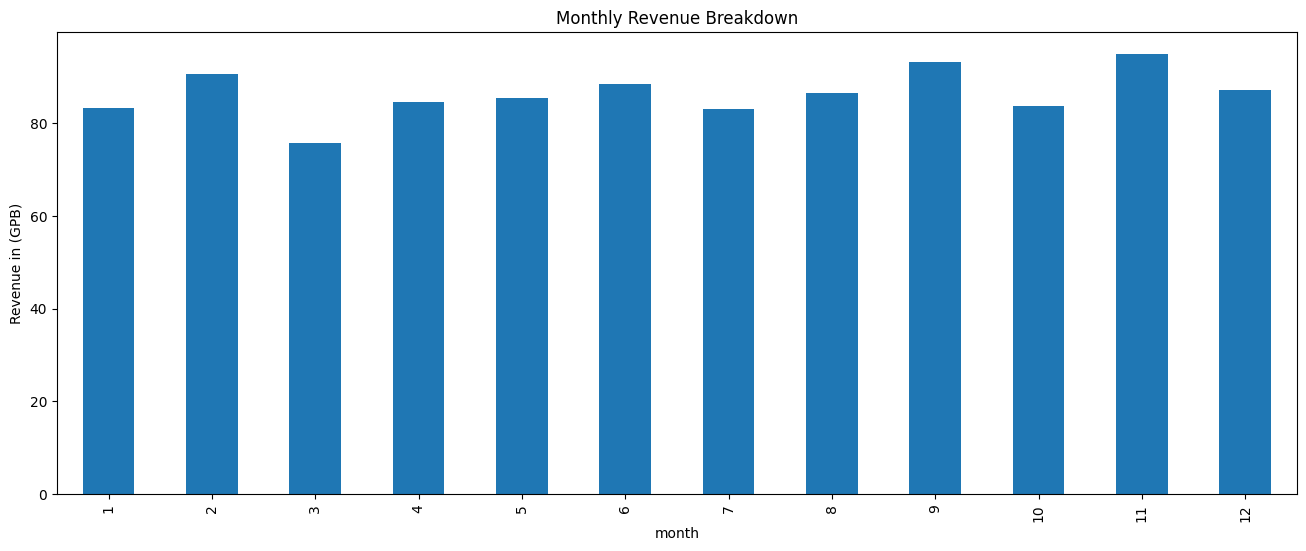

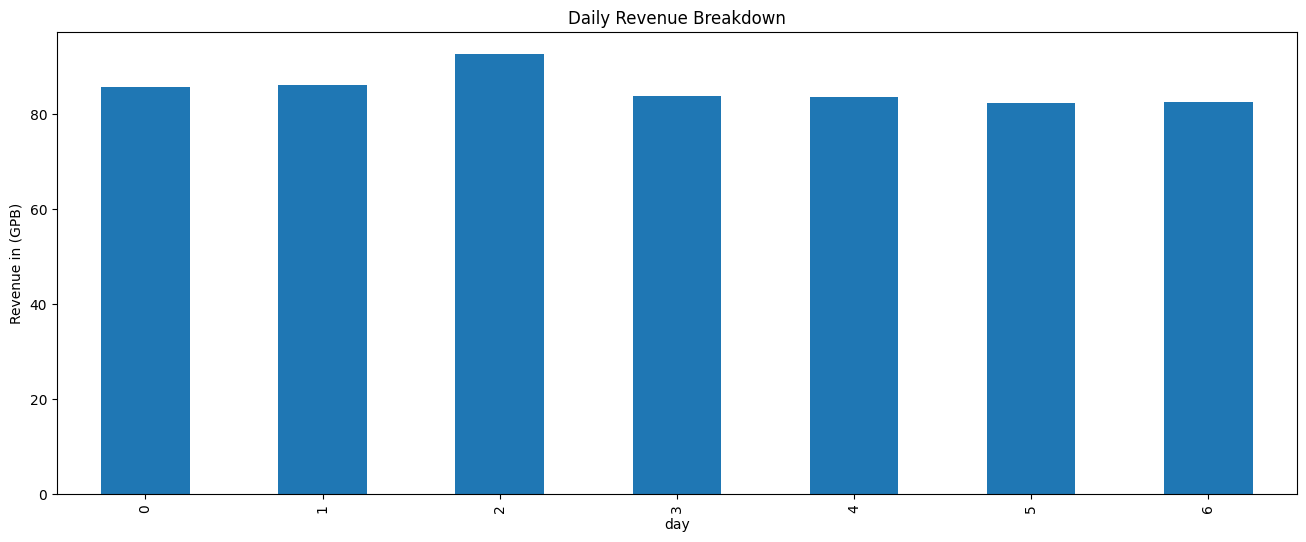

In [25]:
monthly_revenue = df.groupby("month")["revenue"].mean()
daily_revenue = df.groupby("day")["revenue"].mean()

plt.figure(figsize=(16,6))
monthly_revenue.plot(kind="bar")
plt.ylabel("Revenue in (GPB)")
plt.title("Monthly Revenue Breakdown")
plt.show()

plt.figure(figsize=(16,6))
daily_revenue.plot(kind="bar")
plt.ylabel("Revenue in (GPB)")
plt.title("Daily Revenue Breakdown")
plt.show()

[1] Generally balanced distribution of revenue acrros the year, with slightly higher increase in Februray, October and November. With regard to days the revenue also appears to be evenly spread with slight increasde in Tuesday.  
 [2] Further investigation with regard to the revenue distribution over products and categories might be proven insightful

In [207]:
url = URL.create(
    "mysql+pymysql", 
    port = 3306, 
    username= "root",
    password = getpass("Enter MySQL Password: "),
    database= "customers_orders",
    host= "localhost"
)

engine = create_engine(url)

df.to_sql("customers_orders", engine, if_exists="fail" ,index= False)

2180